In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression

In [2]:
tips = sns.load_dataset("tips")

print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [3]:
tips["tip_percent"] = (tips["tip"] / tips["total_bill"]) * 100

print(tips.head())

   total_bill   tip     sex smoker  day    time  size  tip_percent
0       16.99  1.01  Female     No  Sun  Dinner     2     5.944673
1       10.34  1.66    Male     No  Sun  Dinner     3    16.054159
2       21.01  3.50    Male     No  Sun  Dinner     3    16.658734
3       23.68  3.31    Male     No  Sun  Dinner     2    13.978041
4       24.59  3.61  Female     No  Sun  Dinner     4    14.680765


In [13]:
    male = tips[tips["sex"]=="Male"]["tip_percent"]
female = tips[tips["sex"]=="Female"]["tip_percent"]

f_stat, p_value = f_oneway(male, female)

print("ANOVA (Gender)")
print("F-stat:", f_stat)
print("p-value:", p_value)

ANOVA (Gender)
F-stat: 1.1737495515748595
p-value: 0.27971038496054923


In [5]:
smoker = tips[tips["smoker"]=="Yes"]["tip_percent"]
nonsmoker = tips[tips["smoker"]=="No"]["tip_percent"]

f_stat, p_value = f_oneway(smoker, nonsmoker)

print("ANOVA (Smoker)")
print("F-stat:", f_stat)
print("p-value:", p_value)

ANOVA (Smoker)
F-stat: 0.2300826376186187
p-value: 0.6318957776878537


In [6]:
groups = [group["tip_percent"].values for name, group in tips.groupby("day")]

f_stat, p_value = f_oneway(*groups)

print("ANOVA (Day)")
print("F-stat:", f_stat)
print("p-value:", p_value)

ANOVA (Day)
F-stat: 0.848004878913012
p-value: 0.4688408992352633


C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_7648\2086216956.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["tip_percent"].values for name, group in tips.groupby("day")]


In [7]:
X = tips[["total_bill"]]
y = tips["tip"]

model = LinearRegression()

model.fit(X, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [0.10502452]
Intercept: 0.9202696135546731


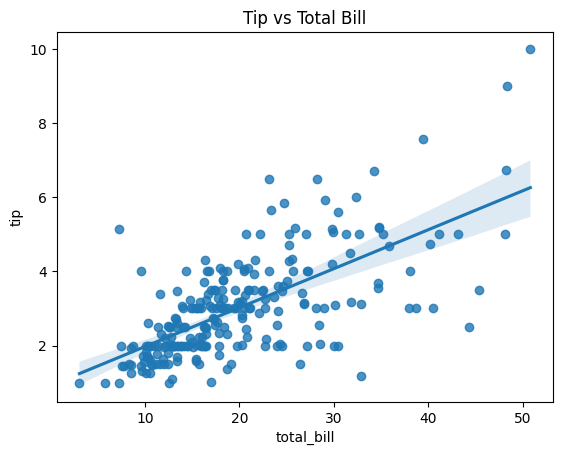

In [8]:
sns.regplot(x="total_bill", y="tip", data=tips)

plt.title("Tip vs Total Bill")

plt.show()

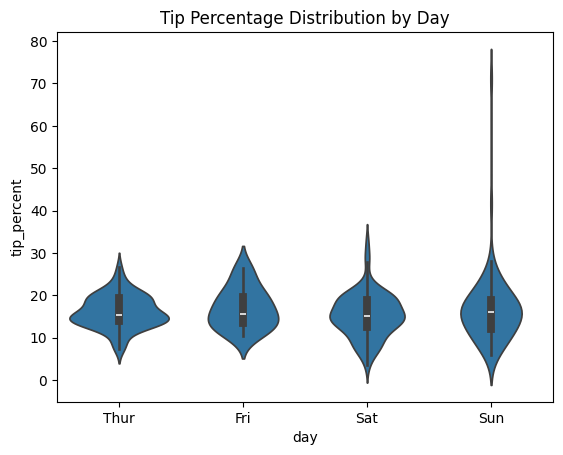

In [9]:
sns.violinplot(x="day", y="tip_percent", data=tips)

plt.title("Tip Percentage Distribution by Day")

plt.show()

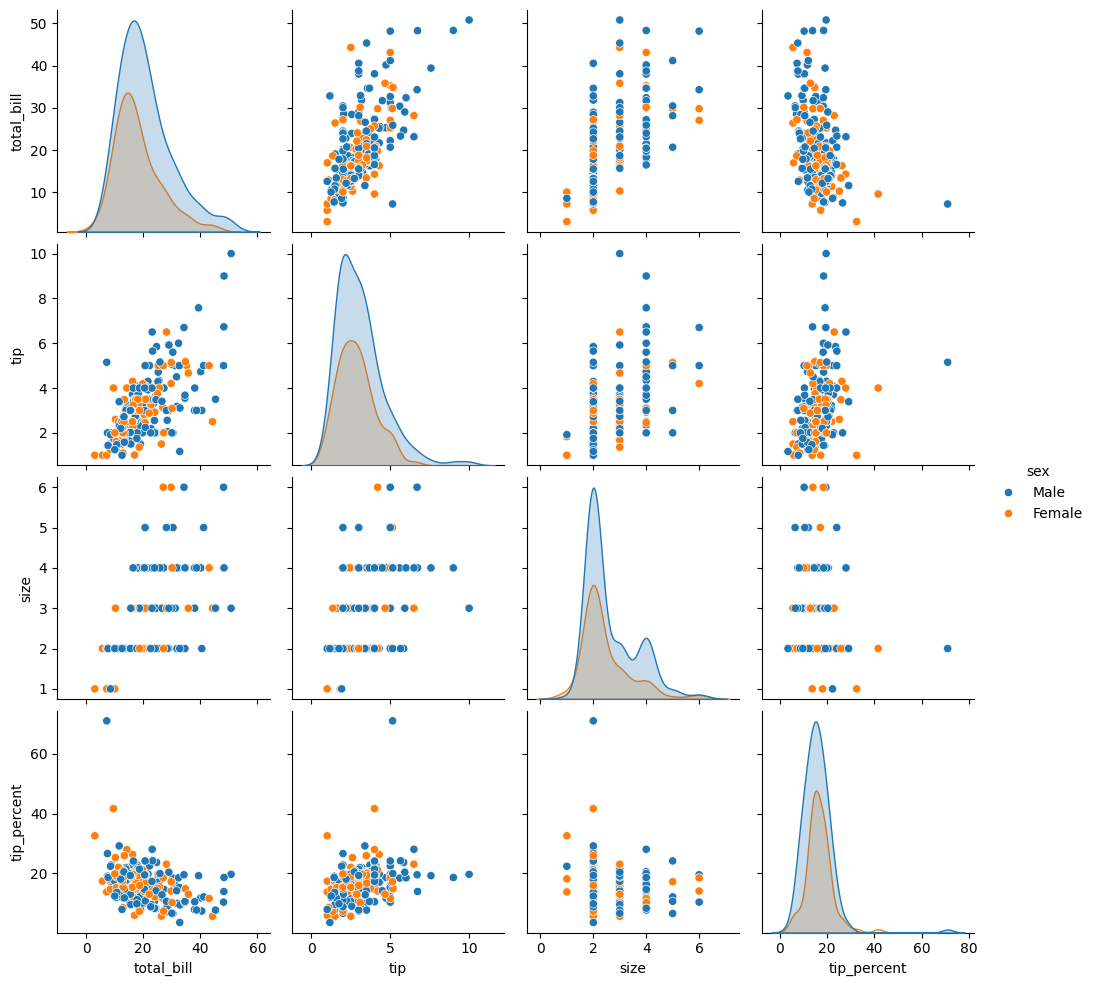

In [ ]:
sns.pairplot(tips, hue="sex")

plt.show()

In [ ]:
fig = px.bar(
    tips,
    x="day",
    y="tip_percent",
    color="sex",
    barmode="group",
    title="Average Tip Percentage by Day and Gender"
)

fig.show()



In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
tips = sns.load_dataset("tips")

print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [16]:
tips_encoded = pd.get_dummies(tips, drop_first=True)

In [17]:
X = tips_encoded.drop("tip", axis=1)
y = tips_encoded["tip"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)e

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.7033566017436106
R2 Score: 0.43730181943482493


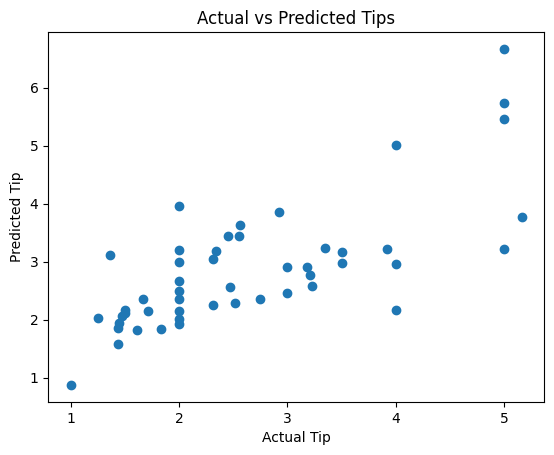

In [22]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")

plt.title("Actual vs Predicted Tips")

plt.show()

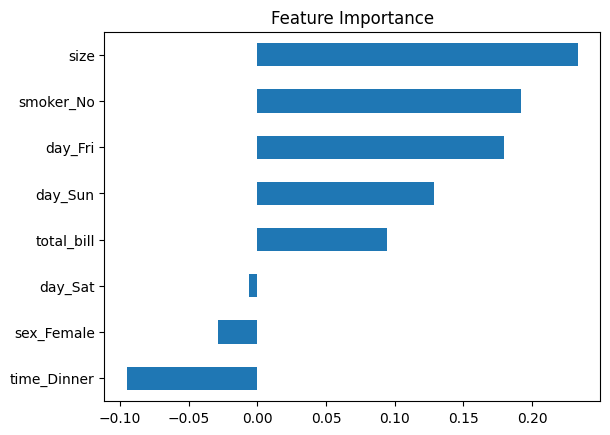

In [23]:
importance = pd.Series(model.coef_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

In [26]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

In [27]:
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

In [43]:
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix



tips = sns.load_dataset("tips")
tips["high_tip"] = (tips["tip"] >= tips["tip"].median()).astype(int)
tips_encoded = pd.get_dummies(tips, drop_first=True)
X = tips_encoded.drop(["tip", "high_tip"], axis=1)
y = tips_encoded["high_tip"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
y_probs = model.predict_proba(X_test)[:, 1]

In [45]:
thresholds = np.arange(0.1, 1.0, 0.1)

frames = []

for threshold in thresholds:
    
    y_pred = (y_probs >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)

    frames.append(go.Frame(
        data=[go.Heatmap(
            z=cm,
            x=['Low Tip', 'High Tip'],
            y=['Low Tip', 'High Tip'],
            text=cm,
            texttemplate='%{text}',
            colorscale='Blues'
        )],
        name=str(round(threshold, 1))
    ))

# Initial matrix
y_pred_init = (y_probs >= thresholds[0]).astype(int)
cm_init = confusion_matrix(y_test, y_pred_init)

fig = go.Figure(
    data=[go.Heatmap(
        z=cm_init,
        x=['Low Tip', 'High Tip'],
        y=['Low Tip', 'High Tip'],
        text=cm_init,
        texttemplate='%{text}',
        colorscale='Blues'
    )],
    frames=frames
)

fig.update_layout(
    title="Animated Confusion Matrix (Tip Prediction)",
    xaxis_title="Predicted",
    yaxis_title="Actual",
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'buttons': [
            {'label': 'Play', 'method': 'animate',
             'args': [None, {'frame': {'duration': 500}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate',
             'args': [[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]}
        ]
    }],
    sliders=[{
        'active': 0,
        'steps': [{'args': [[f.name], {'frame': {'duration': 300}, 'mode': 'immediate'}],
                  'label': f'Threshold: {f.name}', 'method': 'animate'} for f in frames],
        'transition': {'duration': 300}
    }]
)

fig.show()